# Point-in-time correctness and the bond-graph audit

This studybook explains why a chronological train/test split is **necessary but not sufficient**, how a label becomes available, how strictly-prior company history is constructed, and why the stored bond-graph features are quarantined. It assumes only the graph schema and fixed-origin split introduced in notebooks `00` and `01`; no knowledge of temporal GNNs is required.

The central rule is simple: when predicting an invoice at time $t_i$, every feature, edge, fitted transform, and supervised label must have been observable at or before the relevant decision time.

## 1. Two clocks, not one

Each example has a **prediction clock** (when the invoice is scored) and a **label clock** (when its outcome becomes known). For p90, a conservative availability time is `due_date + 90 days`. For impairment, a positive needs an impairment-event timestamp and a negative needs a closure/resolution timestamp. A final database label does not tell us either clock by itself.

The diagram below separates legal past information from an outcome that is still in the future.

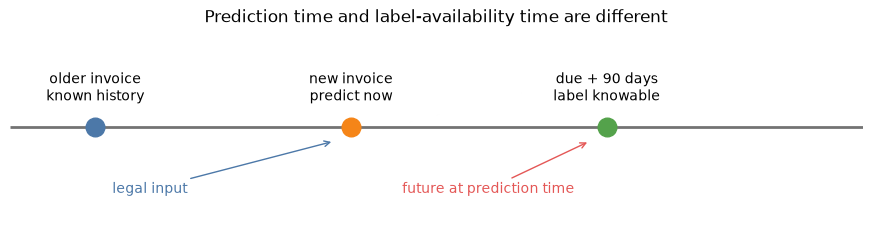

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from graph_ml.data import build_strictly_prior_histories
from graph_ml.evaluation import build_horizon_label_availability

ROOT = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').exists())
DATA = ROOT / 'data'

fig, ax = plt.subplots(figsize=(11, 2.5))
ax.hlines(0, 0, 10, color='0.45', linewidth=2)
events = [(1, 'older invoice\nknown history', '#4c78a8'), (4, 'new invoice\npredict now', '#f58518'), (7, 'due + 90 days\nlabel knowable', '#54a24b')]
for x, label, color in events:
    ax.scatter(x, 0, s=180, color=color, zorder=3)
    ax.text(x, 0.18, label, ha='center', va='bottom', fontsize=10)
ax.annotate('legal input', xy=(3.8, -0.12), xytext=(1.2, -0.55), arrowprops={'arrowstyle': '->', 'color': '#4c78a8'}, color='#4c78a8')
ax.annotate('future at prediction time', xy=(6.8, -0.12), xytext=(4.6, -0.55), arrowprops={'arrowstyle': '->', 'color': '#e45756'}, color='#e45756')
ax.set(xlim=(0, 10), ylim=(-0.8, 0.8), title='Prediction time and label-availability time are different')
ax.axis('off')
plt.show()

## 2. Which target can be evaluated safely now?

We do not substitute `debt_collection_date` for impairment time: its semantics have not been proven. p90 and p180 have explicit horizons, so we can conservatively ask whether `due_date + horizon` is known by the training cutoff $T$ or analysis date $A$. The labels below are used only after that availability test.

,target,cohort,rows,positives,prevalence
0,90,train,38169,3050,7.99%
1,90,test,10554,222,2.10%
2,180,train,29552,2169,7.34%
3,180,test,2504,0,0.00%


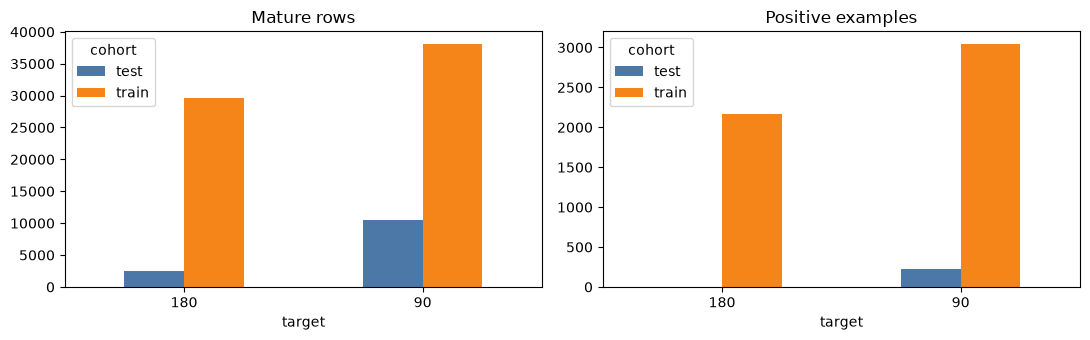

In [2]:
instruments = pd.read_parquet(DATA / '02_instrumentsdf_2.parquet')
invoice_dates = pd.to_datetime(instruments['invoice_date'])
T = pd.Timestamp('2018-04-30')
A = pd.Timestamp('2018-12-18')

rows = []
for target, horizon in [('is_pastdue90', 90), ('is_pastdue180', 180)]:
    availability = build_horizon_label_availability(instruments, target_column=target, horizon_days=horizon)
    train = invoice_dates.lt(T).to_numpy() & availability.known_by(T)
    test = invoice_dates.ge(T).to_numpy() & invoice_dates.le(A).to_numpy() & availability.known_by(A)
    for cohort, mask in [('train', train), ('test', test)]:
        positives = int(instruments.loc[mask, target].sum())
        rows.append({'target': target.removeprefix('is_pastdue'), 'cohort': cohort, 'rows': int(mask.sum()), 'positives': positives, 'prevalence': positives / mask.sum() if mask.sum() else np.nan})
cohorts = pd.DataFrame(rows)
display(cohorts.style.format({'prevalence': '{:.2%}'}))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for ax, metric, title in zip(axes, ['rows', 'positives'], ['Mature rows', 'Positive examples']):
    pivot = cohorts.pivot(index='target', columns='cohort', values=metric)
    pivot.plot.bar(ax=ax, color=['#4c78a8', '#f58518'])
    ax.set_title(title); ax.set_xlabel('target'); ax.tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()

p90 has enough positive examples on both sides of the cutoff. p180 has **zero mature test positives**, so PR-AUC/model discrimination is undefined in the useful sense. This selects p90 for protocol viability—not because we inspected and preferred its model score.

## 3. Strictly-prior company history

A cumulative history must be shifted. If two invoices arrive at the same timestamp, neither may see the other: there is no defensible ordering between simultaneous events. The reusable implementation below returns the history that existed immediately before each event.

,company,time,amount,history_count,history_mean__amount
0,A,2020-01-01,10.0,0,NaN
1,A,2020-01-02,20.0,1,10.000000
2,A,2020-01-02,40.0,1,10.000000
3,A,2020-01-03,50.0,3,23.333333


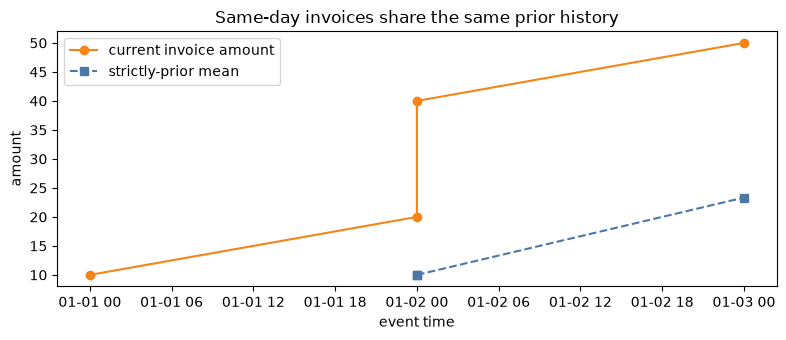

In [3]:
toy = pd.DataFrame({
    'company': ['A', 'A', 'A', 'A'],
    'time': pd.to_datetime(['2020-01-01', '2020-01-02', '2020-01-02', '2020-01-03']),
    'amount': [10.0, 20.0, 40.0, 50.0],
})
history = build_strictly_prior_histories(toy, entity_column='company', timestamp_column='time', value_columns=('amount',))
example = pd.concat([toy, history], axis=1)
display(example)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(example['time'], example['amount'], 'o-', label='current invoice amount', color='#f58518')
ax.plot(example['time'], example['history_mean__amount'], 's--', label='strictly-prior mean', color='#4c78a8')
ax.set(title='Same-day invoices share the same prior history', ylabel='amount', xlabel='event time')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Why the stored bond graph is quarantined

Bond features can leak in four places: post-origination lifecycle inputs, prior invoices whose eventual outcomes were not yet resolved, topology containing future relationships, and propagation of those unsafe values. There is also an artifact-integrity warning. We compare corresponding target-specific columns row by row; a value of 100% means two supposedly different target features are identical everywhere.

,feature family,p90/p180 identical share
0,edge_eff,100.0%
1,edge_flow,100.0%
2,d_node_flow,100.0%
3,c_node_eff,100.0%
4,node_flow,100.0%
5,energy,100.0%
6,flow_shock,100.0%


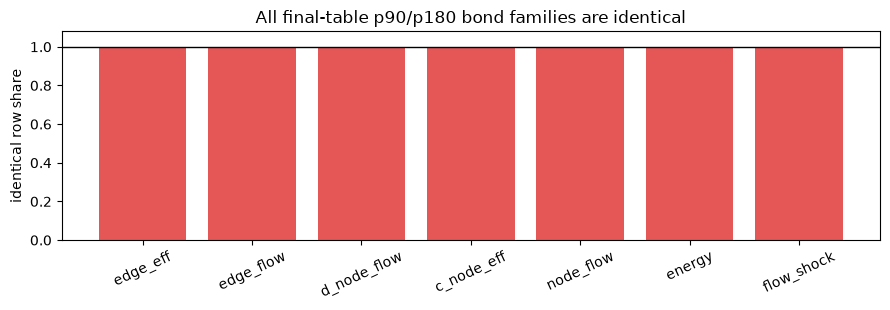

In [4]:
bond = pd.read_parquet(DATA / '04_instrumentsdf_bondgraph.parquet')
final_bond = pd.read_parquet(DATA / '04_instrumentsdf_bondgraph2.parquet')
suffixes = ['edge_eff', 'edge_flow', 'd_node_flow', 'c_node_eff', 'node_flow', 'energy']
checks = []
for suffix in suffixes:
    checks.append((suffix, np.isclose(final_bond[f'p90_{suffix}'], final_bond[f'p180_{suffix}'], equal_nan=True).mean()))
checks.append(('flow_shock', np.isclose(final_bond['flow_shock_p90'], final_bond['flow_shock_p180'], equal_nan=True).mean()))
identity = pd.DataFrame(checks, columns=['feature family', 'p90/p180 identical share'])
display(identity.style.format({'p90/p180 identical share': '{:.1%}'}))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.bar(identity['feature family'], identity['p90/p180 identical share'], color='#e45756')
ax.axhline(1, color='black', linewidth=1); ax.set_ylim(0, 1.08)
ax.set(title='All final-table p90/p180 bond families are identical', ylabel='identical row share')
ax.tick_params(axis='x', rotation=25); plt.tight_layout(); plt.show()

assert (identity['p90/p180 identical share'] == 1).all()
assert np.isclose(bond['flow_shock_imp1'], bond['flow_shock_p180'], equal_nan=True).all()

## 5. The first corrected tabular benchmark

The feature pipeline now asks for each endpoint company's earlier seller-role **and** buyer-role history, which preserves hybrids without using the current or future invoice. Median imputation and category vocabularies are fitted on the early training cohort only during tree-count selection, then refitted on the legally available train+validation cohort.

This p90 score is not comparable to the earlier 0.465 impairment PR-AUC: the target, prevalence, and maturity rule differ. Its purpose is to establish the bar that a temporal p90 GNN must beat.

,model,cohort,review_fraction,sample_count,positive_count,prevalence,pr_auc,roc_auc,top_k,precision_at_k,recall_at_k
0,point_in_time_lightgbm,test_all,0.050000,10554,222,2.10%,0.079,0.819,528,12.88%,30.63%
1,point_in_time_lightgbm,test_seen,0.050000,8119,166,2.04%,0.102,0.867,406,10.59%,25.90%
2,point_in_time_lightgbm,test_cold_start,0.050000,2435,56,2.30%,0.026,0.585,122,0.00%,0.00%


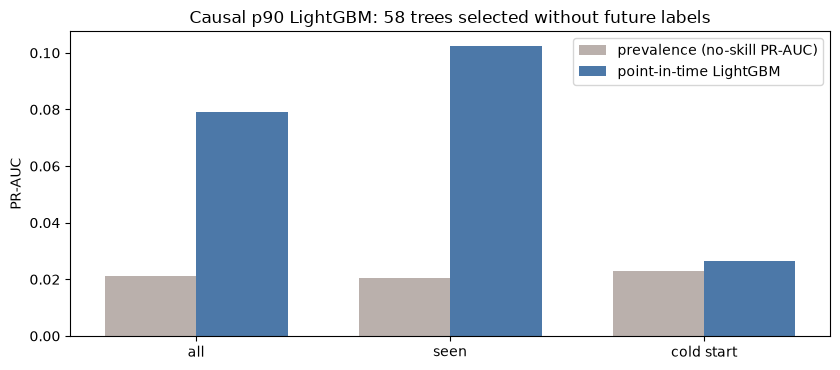

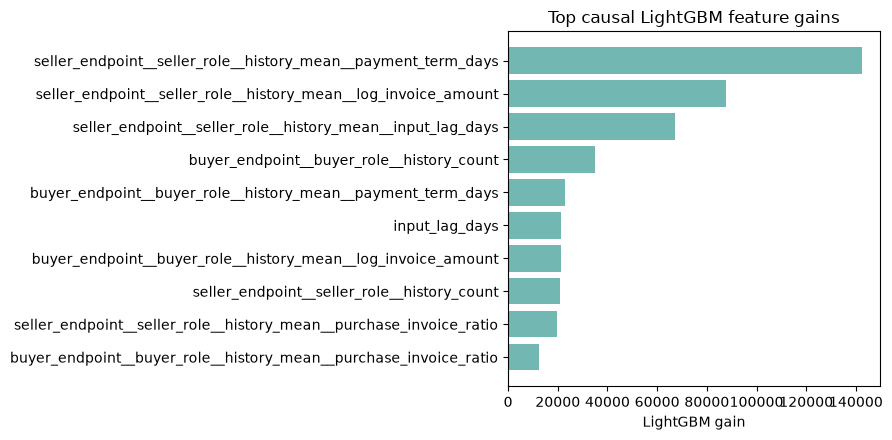

In [5]:
from graph_ml.baselines import (
    build_point_in_time_feature_frame,
    evaluate_point_in_time_run,
    fit_point_in_time_lightgbm,
    point_in_time_cold_start_mask,
)
from graph_ml.evaluation import RollingOriginFoldSpec, build_point_in_time_fold

p90_availability = build_horizon_label_availability(instruments, target_column='is_pastdue90', horizon_days=90)
p90_fold = build_point_in_time_fold(
    instruments['invoice_date'],
    p90_availability,
    RollingOriginFoldSpec('2017-08-01', '2018-04-30', '2018-12-19'),
)
p90_features = build_point_in_time_feature_frame(instruments)
p90_run = fit_point_in_time_lightgbm(p90_features, p90_availability, p90_fold)
cold = point_in_time_cold_start_mask(instruments, cutoff='2018-04-30')
p90_metrics = evaluate_point_in_time_run(
    p90_run,
    p90_availability,
    {
        'test_all': p90_fold.test_mask,
        'test_seen': p90_fold.test_mask & ~cold,
        'test_cold_start': p90_fold.test_mask & cold,
    },
)
display(p90_metrics.style.format({'prevalence': '{:.2%}', 'pr_auc': '{:.3f}', 'roc_auc': '{:.3f}', 'precision_at_k': '{:.2%}', 'recall_at_k': '{:.2%}'}))

fig, ax = plt.subplots(figsize=(8.5, 3.8))
x = np.arange(len(p90_metrics))
ax.bar(x - 0.18, p90_metrics['prevalence'], width=0.36, label='prevalence (no-skill PR-AUC)', color='#bab0ac')
ax.bar(x + 0.18, p90_metrics['pr_auc'], width=0.36, label='point-in-time LightGBM', color='#4c78a8')
ax.set_xticks(x, p90_metrics['cohort'].str.replace('test_', '').str.replace('_', ' '))
ax.set(ylabel='PR-AUC', title=f'Causal p90 LightGBM: {p90_run.best_iteration} trees selected without future labels')
ax.legend(); plt.tight_layout(); plt.show()

top_gains = pd.DataFrame(p90_run.feature_gains[:10], columns=['feature', 'gain']).sort_values('gain')
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.barh(top_gains['feature'], top_gains['gain'], color='#72b7b2')
ax.set(title='Top causal LightGBM feature gains', xlabel='LightGBM gain')
plt.tight_layout(); plt.show()

## Takeaways

1. Time belongs in labels, features, preprocessing, folds, and graph messages—not only in a train/test mask.
2. p90 is the first viable causal target with the current files; impairment waits for verified event timing, and p180 lacks mature test positives.
3. Company histories must use strictly earlier events; simultaneous invoices share the same prior state.
4. Bond propagation cannot repair an unavailable upstream outcome or future topology. The stored bond artifacts also fail cross-target consistency checks, so any future bond ablation must be regenerated inside each fold.
5. The corrected p90 LightGBM reaches PR-AUC 0.079 overall, 0.102 on seen companies, and 0.026 on cold-start companies. The next model must use this identical causal event stream; cold-start is the clearest weakness to address.